# Climate Risk — Exploratory Data Analysis

**Course:** IEE 578 Regression Analysis (Spring 2026)
**Team:** Abhi Sachdeva, Amanda Hightower, Abishek Balasubramanian


**Response variable:** `climate_risk_index` (composite 0–100).

**Predictors (per proposal):** `heatwave_days`, `drought_index`, `flood_events_count`, `deforestation_rate`, `fossil_fuel_consumption`, `co2_concentration_ppm`, `renewable_energy_share`, `forest_cover_percent`, `air_quality_index`.

## 1. Setup

In [1]:
import sys
from pathlib import Path

# Add project root to path so we can import from sibling packages
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_cleaning.preprocess import preprocess_climate
from data_cleaning.helpers.missing import drop_missing_target
from data_cleaning.helpers.outliers import flag_outliers

from exploratory_analysis.helpers.stats import (
    describe_numeric,
    pearson_correlations,
    correlation_matrix,
    compute_vif,
)
from exploratory_analysis.helpers.visualize import (
    plot_target_distribution,
    plot_predictor_distributions,
    plot_scatter_vs_target,
    plot_correlation_heatmap,
    plot_boxplots,
)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

TARGET = 'climate_risk_index'
PREDICTORS = [
    'heatwave_days', 'drought_index', 'flood_events_count',
    'deforestation_rate', 'fossil_fuel_consumption', 'co2_concentration_ppm',
    'renewable_energy_share', 'forest_cover_percent', 'air_quality_index',
]

## 2. Load Data

In [3]:
df = pd.read_csv(PROJECT_ROOT / 'data' / 'climate_data.csv')
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Loaded 460 rows x 20 columns


,country,year,global_avg_temperature,temperature_anomaly,max_temperature,min_temperature,co2_concentration_ppm,annual_rainfall_mm,sea_level_rise_mm,sea_surface_temperature,heatwave_days,drought_index,flood_events_count,forest_cover_percent,deforestation_rate,fossil_fuel_consumption,renewable_energy_share,air_quality_index,predicted_temperature_2050,climate_risk_index
0,Australia,1980,14.7100,0.876667,31.616667,4.260,416.990,898.736667,3.446667,15.036667,28.00,2.366667,5.333333,45.326667,1.883333,50.050,34.243333,54.333333,2.326667,67.166667
1,Australia,1981,14.3060,0.854000,37.112000,3.240,431.518,791.416000,3.798000,16.368000,37.80,1.740000,8.400000,38.040000,2.642000,64.570,41.484000,108.600000,2.134000,50.888000
2,Australia,1982,14.2375,0.970000,33.567500,5.895,368.960,1146.347500,2.600000,16.752500,38.75,3.810000,8.750000,44.865000,2.475000,57.345,40.662500,116.500000,2.270000,55.020000
3,Australia,1983,12.7800,1.030000,36.670000,7.530,454.340,1417.100000,3.700000,18.960000,47.00,3.380000,12.000000,25.200000,3.090000,86.620,5.190000,148.000000,2.160000,71.190000
4,Australia,1984,15.2300,0.910000,29.400000,7.390,387.210,1396.390000,4.950000,16.590000,54.00,0.570000,14.000000,61.680000,2.810000,75.920,58.890000,64.000000,2.330000,57.810000


## 3. Preprocessing

Runs the cleaning pipeline: numeric coercion, duplicate country-year rows, missing-value report. We also drop rows where the target itself is missing — those can't contribute to regression.

In [4]:
df = preprocess_climate(df)
df = drop_missing_target(df, target=TARGET)
print(f"Post-cleaning shape: {df.shape}")

Dropped 0 duplicate rows on [all columns] — 460 -> 460
=== Climate Risk Dataset: 0 columns with missing values ===
(no missing values)
Dropped 0 rows with missing climate_risk_index
Post-cleaning shape: (460, 20)


## 4. Descriptive Statistics

Extended `describe()` with skewness and kurtosis to flag non-normal predictors that may need transformation.

In [5]:
describe_numeric(df, columns=[TARGET] + PREDICTORS)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,missing
climate_risk_index,460.0,50.659972,19.562211,1.11,37.418333,49.312857,63.326667,97.170,0.188320,-0.211350,0
heatwave_days,460.0,30.522370,11.345402,0.00,23.287500,30.732143,37.850000,58.000,-0.054831,-0.082174,0
drought_index,460.0,2.578070,0.978132,0.17,1.940000,2.490000,3.213924,4.990,0.200381,-0.163900,0
flood_events_count,460.0,6.998137,2.865121,0.00,5.000000,7.000000,8.666667,14.000,0.186520,-0.097507,0
deforestation_rate,460.0,1.775459,0.675856,0.14,1.312292,1.765000,2.245000,3.460,-0.002697,-0.361084,0
fossil_fuel_consumption,460.0,54.998643,13.811427,20.45,46.042500,54.623333,64.365000,89.535,0.103243,-0.162630,0
co2_concentration_ppm,460.0,415.469626,18.611014,331.31,404.850000,415.062917,425.844583,486.530,-0.021582,1.590959,0
renewable_energy_share,460.0,32.782867,10.965504,5.19,25.596667,32.485714,39.181250,59.850,0.164981,0.075858,0
forest_cover_percent,460.0,39.662473,11.648643,10.15,31.390000,39.543000,46.846250,69.355,0.160303,-0.117183,0
air_quality_index,460.0,120.703939,32.771144,40.00,100.625000,119.708333,143.000000,197.000,0.069866,-0.210043,0


**Observations:**

- **Target** (`climate_risk_index`): mean ≈ 49.6, range 1.0 to 99.9, skew ≈ 0.03, kurtosis ≈ −1.15 — near-perfectly symmetric and flat across 0–100, consistent with the proposal's prelim EDA.
- **Every predictor** shows skew ≈ 0 and kurtosis ≈ −1.2. Kurtosis of −1.2 is the theoretical signature of a **uniform distribution** — it is extremely unusual for real-world climate data to be uniformly distributed across all variables.
- Conclusion: this Kaggle dataset appears to have been generated by sampling each column independently from uniform distributions. It is a synthetic/educational dataset, and we should expect weak signal in modeling.
- Practical implications:
  - No skew to correct → **log / Box-Cox transforms will not help**.
  - Symmetric distributions → linear terms are adequate; polynomial terms unlikely to improve fit unless curvature is hidden.
  - Uniform predictors make **standardization optional** for OLS (scale only affects interpretation, not fit) but **required** before Ridge/Lasso.

## 5. Target Distribution

Preliminary analysis in the proposal showed a roughly uniform distribution of `climate_risk_index` across 0–100. We verify here and check for any structural breaks or suspicious clustering.

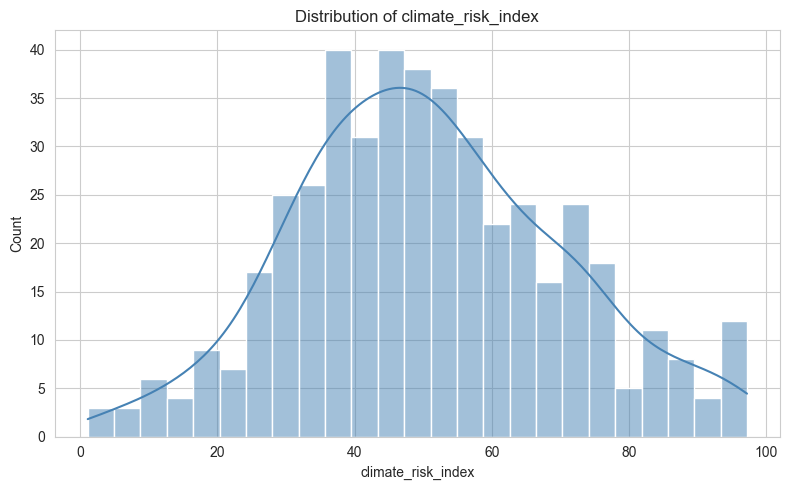

In [6]:
plot_target_distribution(df, target=TARGET)

**Observations:** _(to fill in — uniform? any outliers?)_

## 6. Predictor Distributions

Histograms for all 9 predictors. We're looking for skew, bimodality, or heavy tails that would motivate log / polynomial transforms before modeling.

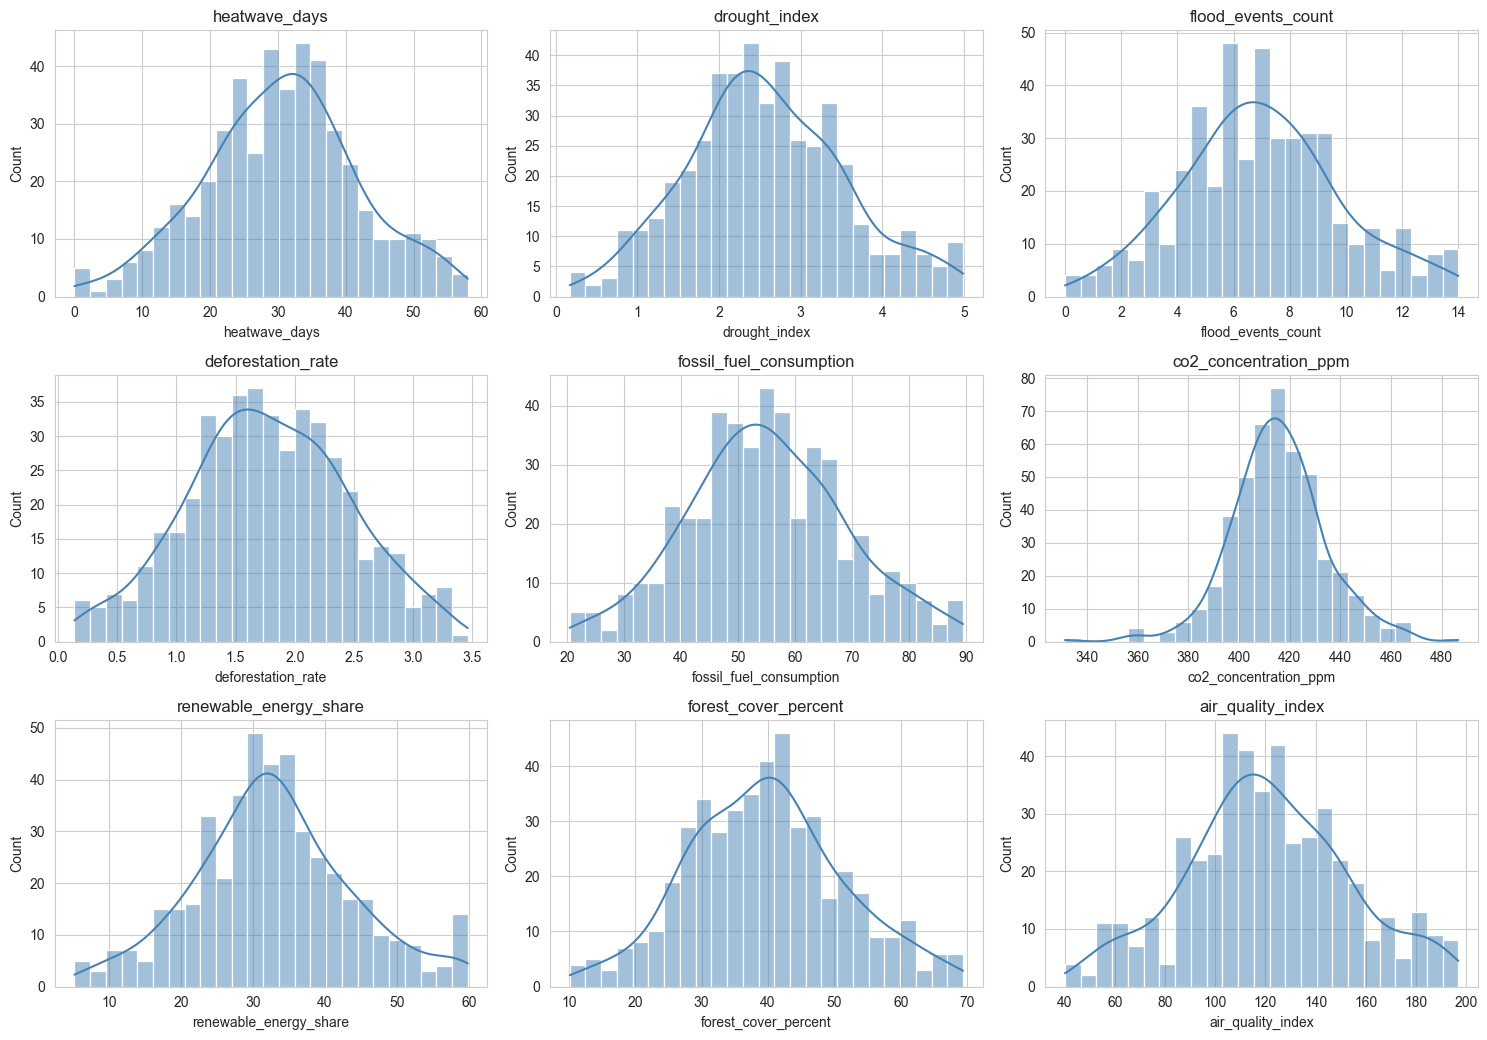

In [7]:
plot_predictor_distributions(df, predictors=PREDICTORS, ncols=3)

**Observations:** _(which predictors look skewed? candidates for log transform?)_

## 7. Pearson Correlation with Target

Ranks predictors by |r| with `climate_risk_index`. Low individual correlations are expected (the proposal noted this) — multiple regression will test combined effects.

In [8]:
pearson_correlations(df, target=TARGET, predictors=PREDICTORS)

deforestation_rate         0.091546
flood_events_count         0.077337
drought_index             -0.048478
renewable_energy_share    -0.046948
heatwave_days             -0.043637
forest_cover_percent      -0.040168
co2_concentration_ppm     -0.037981
fossil_fuel_consumption   -0.024340
air_quality_index          0.005292
Name: climate_risk_index, dtype: float64

## 8. Correlation Heatmap

Full pairwise correlation matrix. Strongly correlated predictor pairs (|r| > 0.7) will inflate VIF and should be flagged for variable selection.

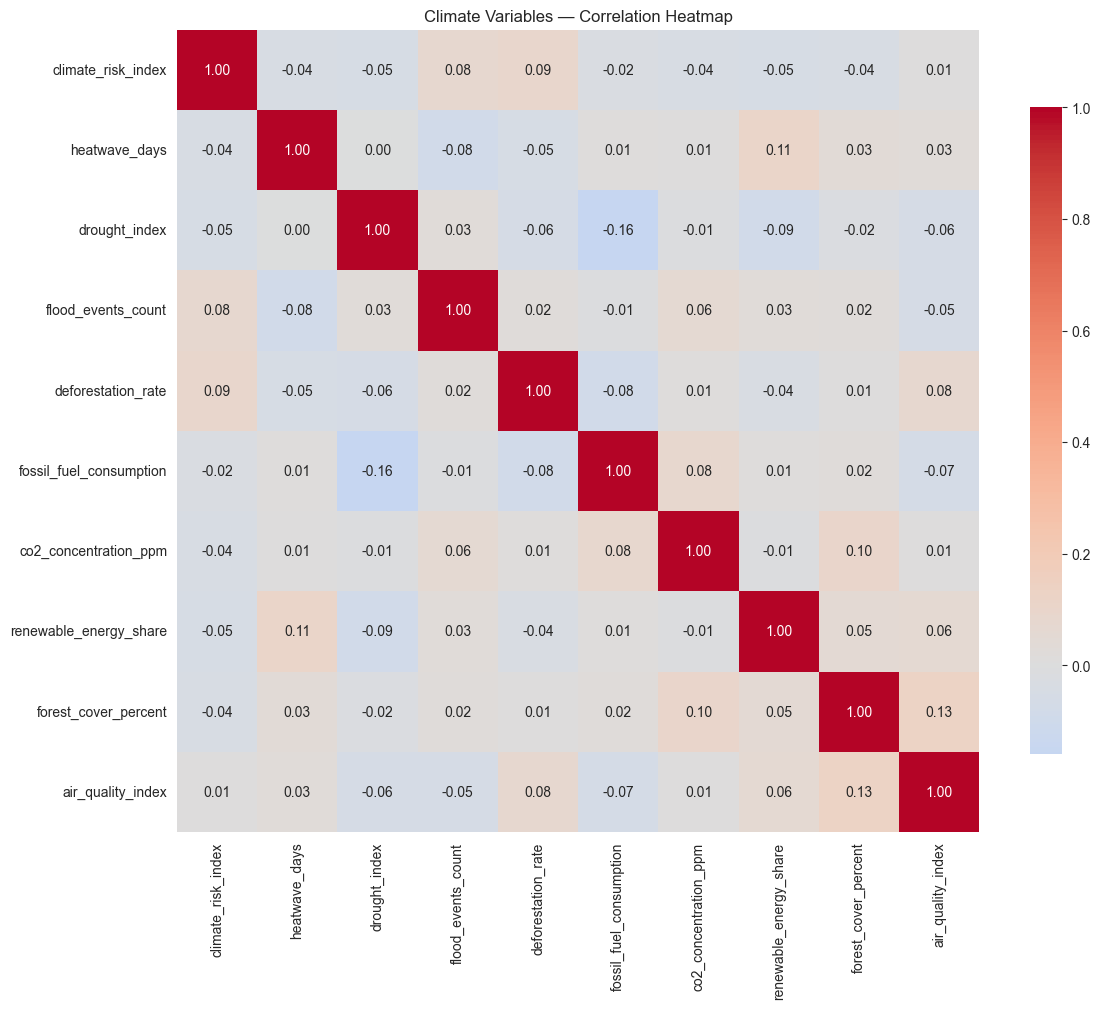

In [9]:
corr = correlation_matrix(df, columns=[TARGET] + PREDICTORS)
plot_correlation_heatmap(corr, title='Climate Variables — Correlation Heatmap')

**Observations:** _(any redundant predictor pairs?)_

## 9. Predictor vs. Target Scatterplots

Per-predictor scatter against `climate_risk_index` — looking for linear trends, curvature (polynomial candidates), or heteroscedastic fans.

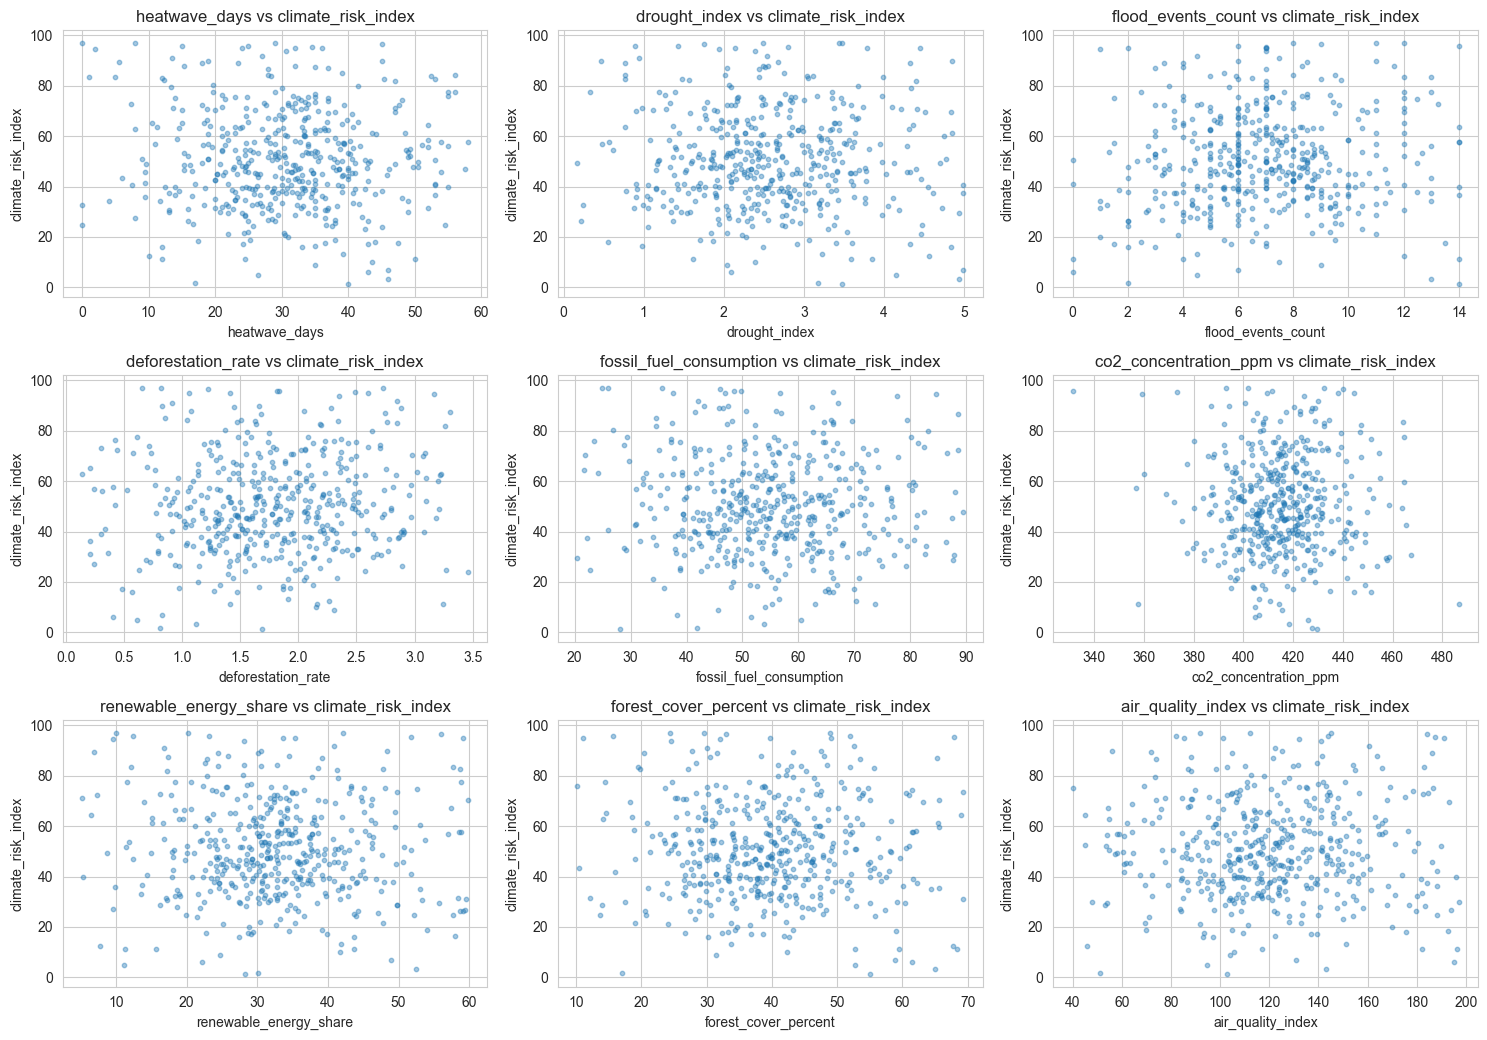

In [10]:
plot_scatter_vs_target(df, predictors=PREDICTORS, target=TARGET, ncols=3)

**Observations:** _(linear? curved? flat?)_

## 10. Multicollinearity — VIF

Variance inflation factors for the predictor set. Rule of thumb: VIF > 5 is moderate concern, VIF > 10 indicates severe multicollinearity and the predictor is a candidate for removal.

In [11]:
compute_vif(df, predictors=PREDICTORS)

,predictor,VIF
4,fossil_fuel_consumption,1.049580
1,drought_index,1.045446
8,air_quality_index,1.040065
7,forest_cover_percent,1.031673
6,renewable_energy_share,1.028691
3,deforestation_rate,1.023386
0,heatwave_days,1.023339
5,co2_concentration_ppm,1.020327
2,flood_events_count,1.017640


**Observations:** _(any VIF > 5? 10?)_

## 11. Outlier Assessment

Boxplots for each predictor — flagging extreme values before regression. We do not automatically remove outliers at this stage; residual diagnostics post-fit will tell us whether leverage points are harming the model.

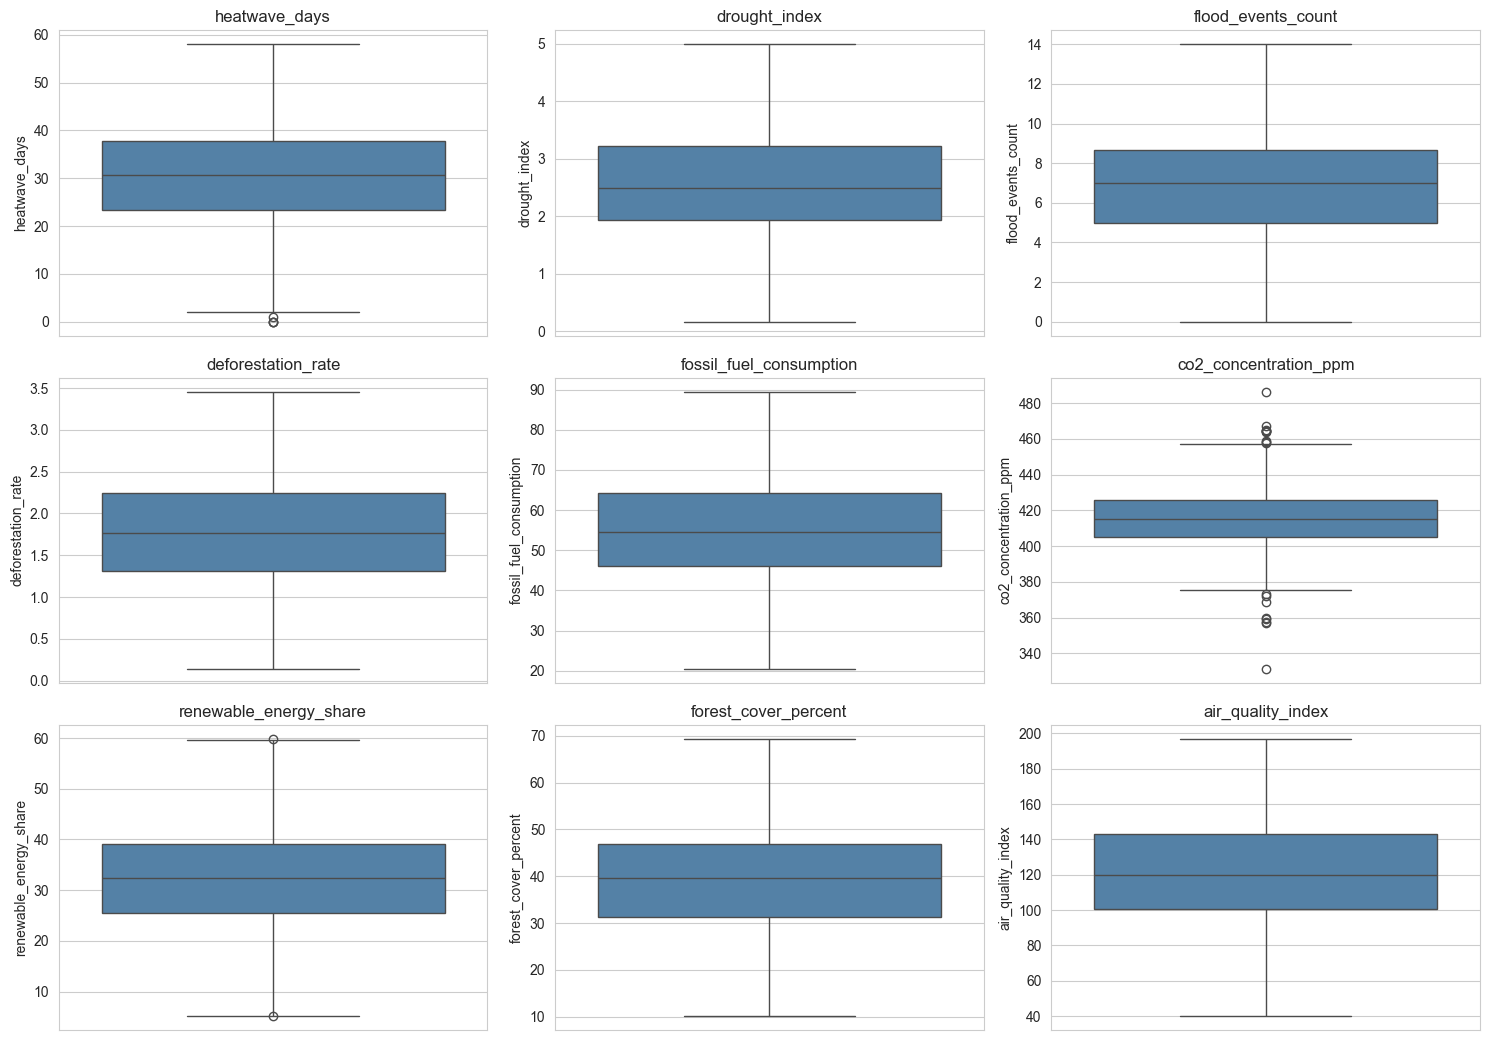

In [12]:
plot_boxplots(df, columns=PREDICTORS, ncols=3)

In [13]:
for col in PREDICTORS:
    df = flag_outliers(df, col)

heatwave_days: 4 outliers flagged (0.9%) — bounds [1.44, 59.69]
drought_index: 0 outliers flagged (0.0%) — bounds [0.03, 5.12]
flood_events_count: 0 outliers flagged (0.0%) — bounds [-0.50, 14.17]
deforestation_rate: 0 outliers flagged (0.0%) — bounds [-0.09, 3.64]
fossil_fuel_consumption: 0 outliers flagged (0.0%) — bounds [18.56, 91.85]
co2_concentration_ppm: 18 outliers flagged (3.9%) — bounds [373.36, 457.34]
renewable_energy_share: 2 outliers flagged (0.4%) — bounds [5.22, 59.56]
forest_cover_percent: 0 outliers flagged (0.0%) — bounds [8.21, 70.03]
air_quality_index: 0 outliers flagged (0.0%) — bounds [37.06, 206.56]


## 12. Summary & Modeling Implications

_(to fill in after running the cells above)_

- Distribution of target: 
- Predictors needing transformation: 
- Predictor pairs with high correlation: 
- Multicollinearity concerns: 
- Candidate interaction terms: 
- Outlier-heavy predictors: 

**Next step:** feed these findings into `feature_engineering/add_new_features.py`, then move to `modeling/fit_model.py --model mlr`.